# Naive Bayes Classification for Bank Loan Prediction

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [5]:
try:
    df = pd.read_csv('bank_loan_dataset.csv')
    print('Dataset loaded successfully!')
    print(df.head())
except FileNotFoundError:
    print("Error: 'bank_loan_dataset.csv' not found. Please upload the dataset or provide the correct path.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: 'bank_loan_dataset.csv' not found. Please upload the dataset or provide the correct path.


## Generate Synthetic Dataset (since `bank_loan_dataset.csv` was not found)

In [6]:
np.random.seed(42)

data = {
    'age': np.random.randint(20, 65, 1000),
    'income': np.random.randint(30000, 120000, 1000),
    'loan_amount': np.random.randint(5000, 50000, 1000),
    'credit_score': np.random.randint(300, 850, 1000),
    'employment_years': np.random.randint(0, 30, 1000),
    'debt_to_income_ratio': np.random.uniform(0.1, 0.5, 1000),
    'loan_approved': np.random.choice([0, 1], 1000, p=[0.3, 0.7]) # 70% approval rate
}

df = pd.DataFrame(data)

print('Synthetic dataset generated successfully!')
display(df.head())

Synthetic dataset generated successfully!


,age,income,loan_amount,credit_score,employment_years,debt_to_income_ratio,loan_approved
0,58,53930,18598,601,15,0.234403,0
1,48,30077,24508,759,17,0.286273,1
2,34,50611,47287,700,29,0.409352,0
3,62,46984,18380,692,15,0.465986,1
4,27,44060,31984,506,22,0.175656,1


## Data Preprocessing

In [7]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print("Data split successfully!")

Training set size: 700 samples
Test set size: 300 samples
Data split successfully!


## Naive Bayes Model Implementation

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the Naive Bayes classifier (Gaussian Naive Bayes for continuous data)
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Naive Bayes Model trained and predictions made.")

Naive Bayes Model trained and predictions made.


## Model Evaluation

Accuracy: 0.7300
Precision: 0.7300
Recall: 1.0000
F1-Score: 0.8439

Confusion Matrix:
[[  0  81]
 [  0 219]]


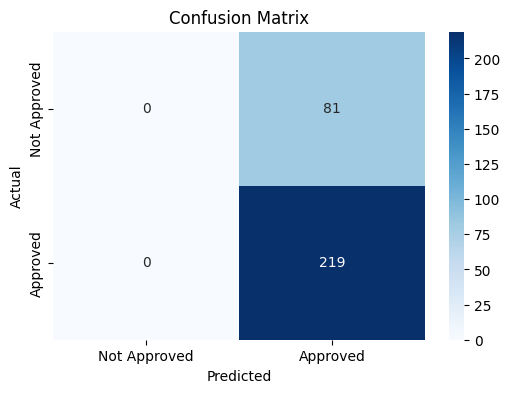

In [9]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Check for Class Imbalance